<a href="https://colab.research.google.com/github/heidy0099/Proy.Org/blob/main/Codigo_final_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# EJECUTAR ESTA CELDA PRIMERO - Carga y preparación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

# Subir archivo
print(" Sube el archivo: Proyecto 3 Quimica Organica(Base de Datos) (1).csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Cargar datos
df = pd.read_csv(io.BytesIO(uploaded[filename]), delimiter=';', encoding='latin1')
df.columns = df.columns.str.strip()

# Limpiar nombres de columnas (mapeo)
column_mapping = {}
for col in df.columns:
    col_lower = col.lower()
    if 'grupo' in col_lower and 'funcional' in col_lower:
        column_mapping[col] = 'Grupo_Funcional'
    elif 'pm_sustrato' in col_lower:
        column_mapping[col] = 'PM_Sustrato'
    elif 'pe_sustrato' in col_lower:
        column_mapping[col] = 'PE_Sustrato'
    elif 'pka_sustrato' in col_lower:
        column_mapping[col] = 'pKa_Sustrato'
    elif 'ld50_sustrato' in col_lower:
        column_mapping[col] = 'LD50_Sustrato'
    elif 'tipo_reaccion' in col_lower:
        column_mapping[col] = 'Tipo_Reaccion'
    elif 'nombre_reaccion' in col_lower:
        column_mapping[col] = 'Nombre_Reaccion'
    elif 'nombre_solvente 1' in col_lower:
        column_mapping[col] = 'Nombre_Solvente_1'
    elif 'pm_producto' in col_lower:
        column_mapping[col] = 'PM_Producto'
    elif 'pe_producto' in col_lower:
        column_mapping[col] = 'PE_Producto'
    elif 'pka_producto' in col_lower:
        column_mapping[col] = 'pKa_Producto'
    elif 'nombre_catalizador 1' in col_lower:
        column_mapping[col] = 'Nombre_Catalizador_1'
    elif 'id' in col_lower:
        column_mapping[col] = 'ID'

df.rename(columns=column_mapping, inplace=True)

# Función para limpiar valores numéricos (maneja comas y puntos)
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return x if x > 0 else np.nan
    try:
        # Reemplazar coma por punto y eliminar ';' si existe
        x_str = str(x).strip().replace(',', '.').replace(';', '')
        # Si es un rango como "100-101", tomar el promedio
        if '-' in x_str:
            parts = x_str.split('-')
            val = (float(parts[0]) + float(parts[1])) / 2
        else:
            val = float(x_str)
        return val if val > 0 else np.nan
    except:
        return np.nan

# Aplicar limpieza a columnas numéricas
for col in ['PM_Sustrato', 'PE_Sustrato', 'pKa_Sustrato', 'LD50_Sustrato',
            'PM_Producto', 'PE_Producto', 'pKa_Producto']:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# Limpiar columnas de texto
for col in ['Grupo_Funcional', 'Tipo_Reaccion', 'Nombre_Reaccion', 'Nombre_Solvente_1', 'Nombre_Catalizador_1']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        # Reemplazar valores no válidos
        df[col] = df[col].replace(['0', 'nan', 'None', '', '0;0', '0;0;0'], np.nan)

print(f" Datos cargados: {len(df)} filas")
print(f" Columnas disponibles: {list(df.columns)}")

 Sube el archivo: Proyecto 3 Quimica Organica(Base de Datos) (1).csv


Saving Proyecto 3 Quimica Organica(Base de Datos) (1).csv to Proyecto 3 Quimica Organica(Base de Datos) (1).csv
 Datos cargados: 242 filas
 Columnas disponibles: ['ID', 'Grupo_Funcional', 'Función química', 'Nombre_Sustrato', 'Formula_Sustrato', 'PM_Sustrato', 'PE_Sustrato', 'ID', 'ID', 'ID', 'pKa_Sustrato', 'ID', 'LD50_Sustrato', 'Nombre_Reactivo 1', 'Fórmula Molecular 1', 'Nombre_Reactivo 2', 'Fórmula Molecular 2', 'Nombre_Reactivo 3', 'Fórmula Molecular 3', 'Nombre_Catalizador_1', 'Catalizador 1', 'Nombre_Catalizador 2', 'Catalizador 2', 'Nombre_Catalizador 3', 'Catalizador 3', 'Nombre_Catalizador 4', 'Catalizador 4', 'Nombre_Solvente_1', 'Formula Solvente 1', 'Nombre_Solvente 2', 'Formula Solvente 2', 'Nombre_Solvente 3', 'Formula Solvente 3', 'Temperatura', 'Nombre_Medio', 'Medio', 'Nombre_Producto', 'Formula_Producto', 'PM_Producto', 'PE_Producto', 'ID', 'ID', 'ID', 'pKa_Producto', 'ID', 'LD50_Producto Mamifero mg /kg', 'Tipo_Reaccion', 'Nombre_Reaccion', 'Unnamed: 48']


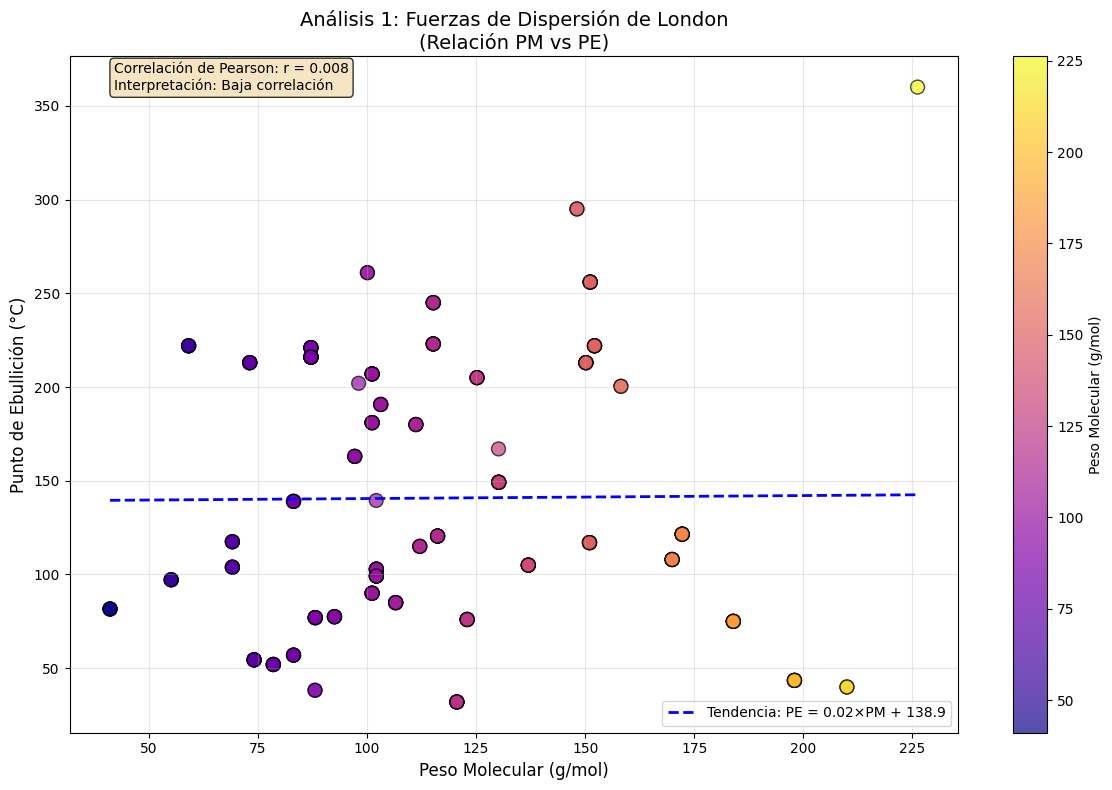


 RESULTADOS ANÁLISIS 1:
   • N° compuestos: 240
   • Correlación (r): 0.008
    Conclusión: Correlación moderada/baja. Factores como puentes de H o dipolos influyen.


In [2]:
# ANÁLISIS 1: PM_Sustrato vs PE_Sustrato
plt.figure(figsize=(12, 8))

# Filtrar datos: PM entre 40-300, PE entre 20-400
plot_df = df.dropna(subset=['PM_Sustrato', 'PE_Sustrato']).copy()
plot_df = plot_df[(plot_df['PM_Sustrato'] >= 40) & (plot_df['PM_Sustrato'] <= 300)]
plot_df = plot_df[(plot_df['PE_Sustrato'] >= 20) & (plot_df['PE_Sustrato'] <= 400)]

if len(plot_df) >= 3:
    # Scatter plot
    scatter = plt.scatter(plot_df['PM_Sustrato'], plot_df['PE_Sustrato'],
                         c=plot_df['PM_Sustrato'], cmap='plasma', s=100, alpha=0.7, edgecolors='black')

    # Línea de tendencia
    z = np.polyfit(plot_df['PM_Sustrato'], plot_df['PE_Sustrato'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plot_df['PM_Sustrato'].min(), plot_df['PM_Sustrato'].max(), 100)
    plt.plot(x_line, p(x_line), 'b--', linewidth=2, label=f'Tendencia: PE = {z[0]:.2f}×PM + {z[1]:.1f}')

    # Correlación
    corr = plot_df['PM_Sustrato'].corr(plot_df['PE_Sustrato'])

    plt.xlabel('Peso Molecular (g/mol)', fontsize=12)
    plt.ylabel('Punto de Ebullición (°C)', fontsize=12)
    plt.title('Análisis 1: Fuerzas de Dispersión de London\n(Relación PM vs PE)', fontsize=14)
    plt.colorbar(scatter, label='Peso Molecular (g/mol)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Anotación
    plt.text(0.05, 0.95, f'Correlación de Pearson: r = {corr:.3f}\nInterpretación: {"Alta" if abs(corr)>0.7 else "Moderada" if abs(corr)>0.4 else "Baja"} correlación',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 1:")
    print(f"   • N° compuestos: {len(plot_df)}")
    print(f"   • Correlación (r): {corr:.3f}")
    if corr > 0.7:
        print("    Conclusión: Fuerte correlación positiva. A mayor masa molar, mayor punto de ebullición.")
    else:
        print("    Conclusión: Correlación moderada/baja. Factores como puentes de H o dipolos influyen.")
else:
    print(f" Datos insuficientes: {len(plot_df)} compuestos (mínimo 3)")

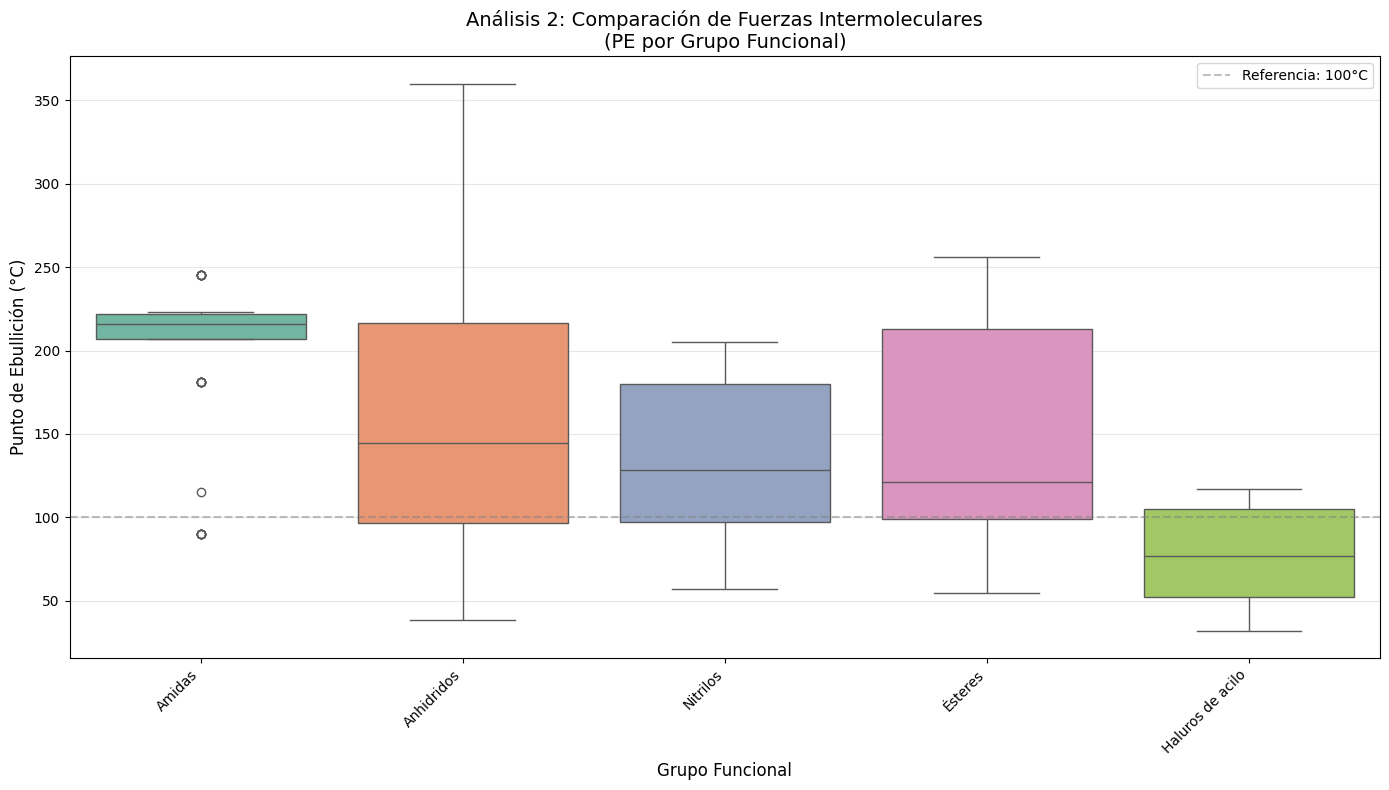


 RESULTADOS ANÁLISIS 2:
   • Amidas: Mediana=216.0°C (n=60)
   • Anhidridos: Mediana=144.3°C (n=20)
   • Nitrilos: Mediana=128.2°C (n=40)
   • Ésteres: Mediana=121.0°C (n=60)
   • Haluros de acilo: Mediana=76.8°C (n=60)

    Conclusión: Amidas (PE≈216°C) > Nitrilos (PE≈128°C)
      → Los puentes de hidrógeno en amidas requieren más energía para romperse.


In [3]:
# ANÁLISIS 2: Grupo Funcional vs PE_Sustrato
plt.figure(figsize=(14, 8))

plot_df = df.dropna(subset=['Grupo_Funcional', 'PE_Sustrato']).copy()
plot_df = plot_df[(plot_df['PE_Sustrato'] >= 20) & (plot_df['PE_Sustrato'] <= 400)]
plot_df = plot_df[~plot_df['Grupo_Funcional'].isin(['nan', 'None', ''])]

# Grupos con al menos 3 datos
grupos_validos = plot_df.groupby('Grupo_Funcional').size()
grupos_validos = grupos_validos[grupos_validos >= 3].index.tolist()
plot_df = plot_df[plot_df['Grupo_Funcional'].isin(grupos_validos)]

if len(plot_df) >= 5:
    # Ordenar por mediana descendente
    order = plot_df.groupby('Grupo_Funcional')['PE_Sustrato'].median().sort_values(ascending=False).index

    sns.boxplot(x='Grupo_Funcional', y='PE_Sustrato', data=plot_df, order=order, palette='Set2')

    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('Punto de Ebullición (°C)', fontsize=12)
    plt.title('Análisis 2: Comparación de Fuerzas Intermoleculares\n(PE por Grupo Funcional)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Referencia: 100°C')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 2:")
    for grupo in order:
        datos = plot_df[plot_df['Grupo_Funcional'] == grupo]['PE_Sustrato']
        print(f"   • {grupo}: Mediana={datos.median():.1f}°C (n={len(datos)})")

    if 'Amidas' in order and 'Nitrilos' in order:
        amidas_pe = plot_df[plot_df['Grupo_Funcional'] == 'Amidas']['PE_Sustrato'].median()
        nitrilos_pe = plot_df[plot_df['Grupo_Funcional'] == 'Nitrilos']['PE_Sustrato'].median()
        print(f"\n   🔍 Conclusión: Amidas (PE≈{amidas_pe:.0f}°C) > Nitrilos (PE≈{nitrilos_pe:.0f}°C)")
        print(f"      → Los puentes de hidrógeno en amidas requieren más energía para romperse.")
else:
    print(f" Datos insuficientes: {len(plot_df)} compuestos (mínimo 5)")

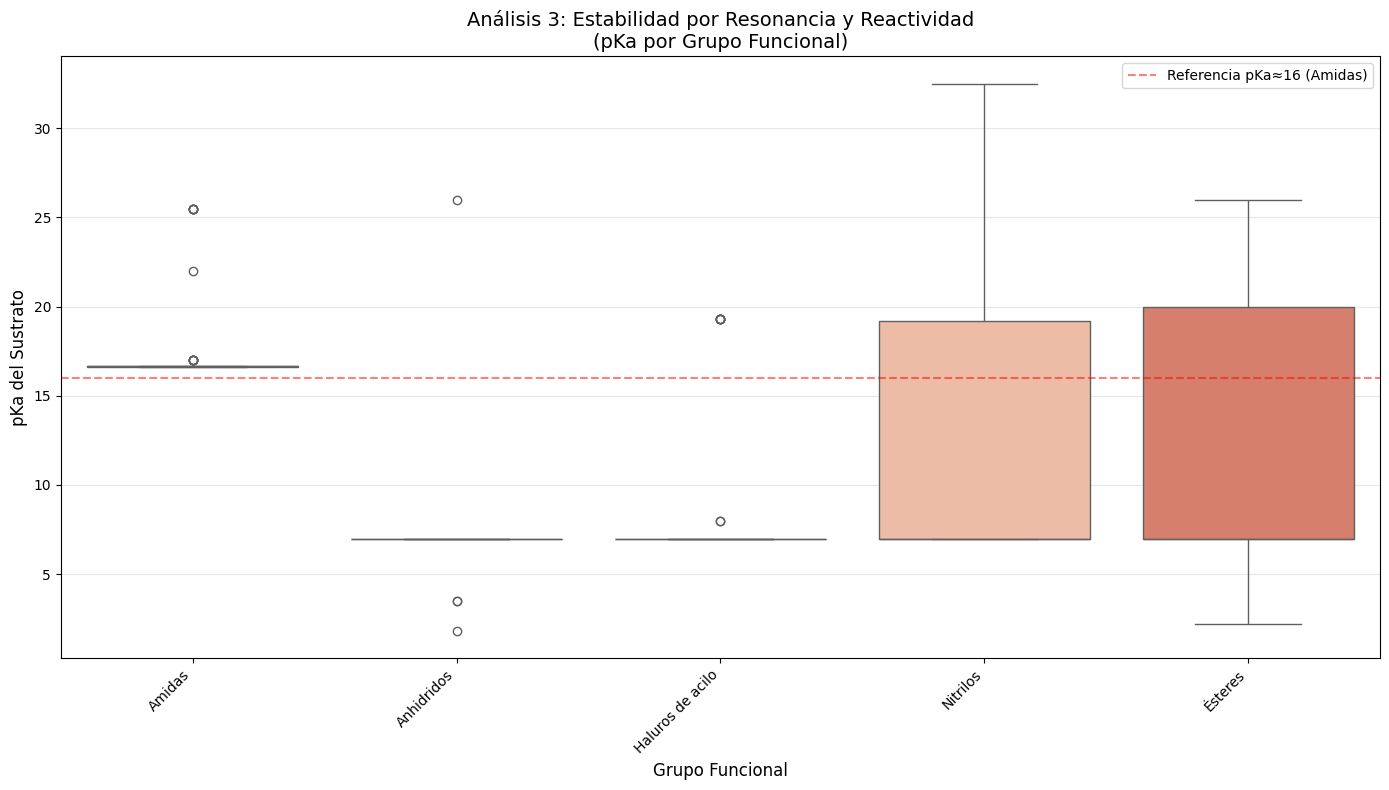


 RESULTADOS ANÁLISIS 3:
   • Amidas: pKa medio=17.51 (n=60)
   • Anhidridos: pKa medio=7.34 (n=20)
   • Haluros de acilo: pKa medio=8.26 (n=60)
   • Nitrilos: pKa medio=13.29 (n=40)
   • Ésteres: pKa medio=11.52 (n=59)

    Interpretación: Amidas (pKa≈17.5) tienen alto pKa.
      → El par de electrones del N está deslocalizado hacia el C=O (resonancia).
      → Por eso son los derivados de ácido MÁS estables y MENOS reactivos.


In [4]:
# ANÁLISIS 3: Grupo Funcional vs pKa_Sustrato
plt.figure(figsize=(14, 8))

plot_df = df.dropna(subset=['Grupo_Funcional', 'pKa_Sustrato']).copy()
plot_df = plot_df[(plot_df['pKa_Sustrato'] > 0) & (plot_df['pKa_Sustrato'] <= 50)]
plot_df = plot_df[~plot_df['Grupo_Funcional'].isin(['nan', 'None', ''])]

# Grupos con al menos 2 datos
grupos_validos = plot_df.groupby('Grupo_Funcional').size()
grupos_validos = grupos_validos[grupos_validos >= 2].index.tolist()
plot_df = plot_df[plot_df['Grupo_Funcional'].isin(grupos_validos)]

if len(plot_df) >= 4:
    # Ordenar por mediana descendente
    order = plot_df.groupby('Grupo_Funcional')['pKa_Sustrato'].median().sort_values(ascending=False).index

    sns.boxplot(x='Grupo_Funcional', y='pKa_Sustrato', data=plot_df, order=order, palette='coolwarm')

    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('pKa del Sustrato', fontsize=12)
    plt.title('Análisis 3: Estabilidad por Resonancia y Reactividad\n(pKa por Grupo Funcional)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.axhline(y=16, color='red', linestyle='--', alpha=0.5, label='Referencia pKa≈16 (Amidas)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 3:")
    for grupo in order:
        datos = plot_df[plot_df['Grupo_Funcional'] == grupo]['pKa_Sustrato']
        print(f"   • {grupo}: pKa medio={datos.mean():.2f} (n={len(datos)})")

    if 'Amidas' in order:
        amigas_pka = plot_df[plot_df['Grupo_Funcional'] == 'Amidas']['pKa_Sustrato'].mean()
        print(f"\n   🔬 Interpretación: Amidas (pKa≈{amigas_pka:.1f}) tienen alto pKa.")
        print(f"      → El par de electrones del N está deslocalizado hacia el C=O (resonancia).")
        print(f"      → Por eso son los derivados de ácido MÁS estables y MENOS reactivos.")
else:
    print(f" Datos insuficientes: {len(plot_df)} compuestos (mínimo 4)")

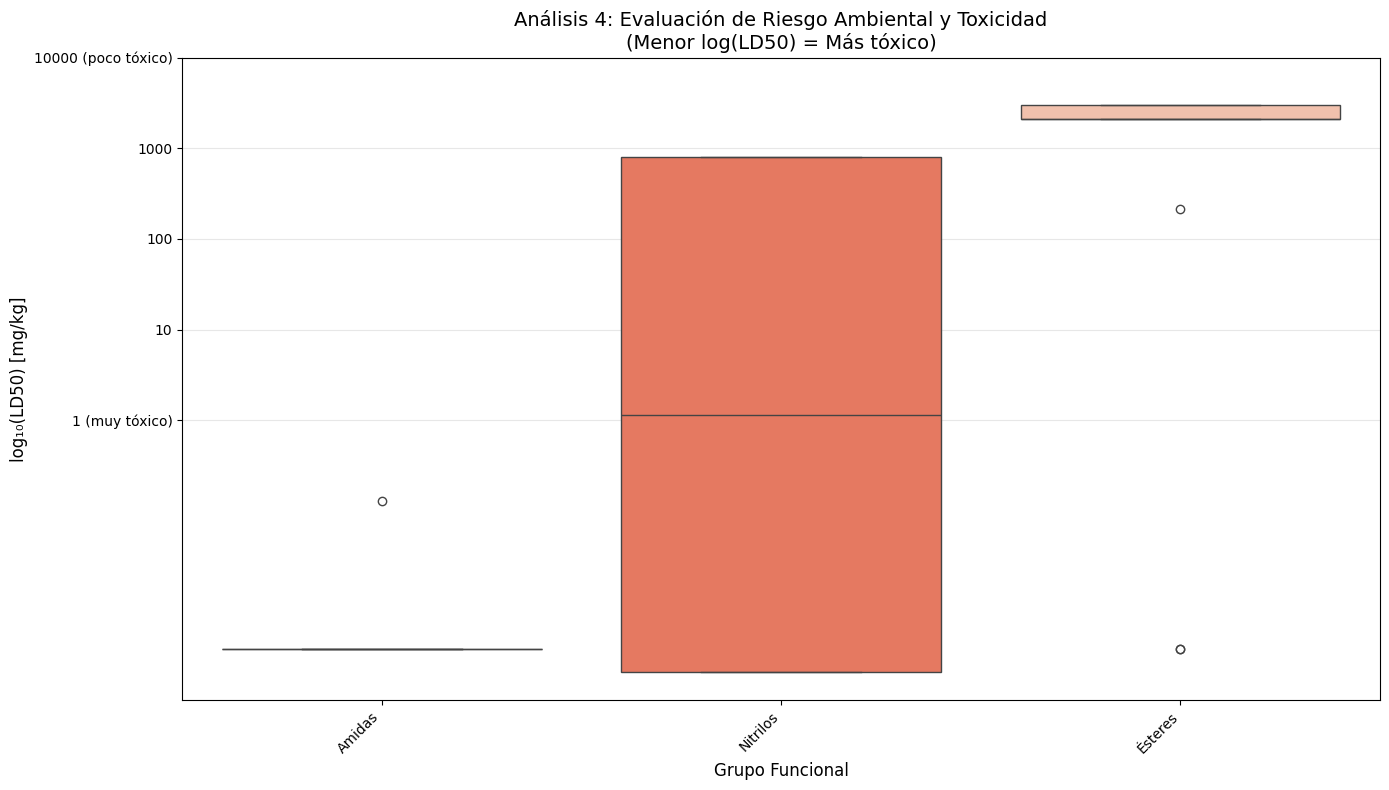


 RESULTADOS ANÁLISIS 4 (Riesgo Ambiental):
    Menor LD50 = Mayor toxicidad. Escala: <50 = Extremo, 50-500 = Tóxico, >500 = Baja

   • Amidas: LD50 mediana = 0.0 mg/kg →  EXTREMADAMENTE TÓXICO
   • Nitrilos: LD50 mediana = 400.0 mg/kg →  TÓXICO
   • Ésteres: LD50 mediana = 2100.0 mg/kg →  BAJA TOXICIDAD

    Precaución: Los nitrilos pueden liberar iones cianuro (CN⁻) en el organismo.


In [5]:
# ANÁLISIS 4: Grupo Funcional vs LD50_Sustrato (Toxicidad)
plt.figure(figsize=(14, 8))

plot_df = df.dropna(subset=['Grupo_Funcional', 'LD50_Sustrato']).copy()
plot_df = plot_df[(plot_df['LD50_Sustrato'] > 0) & (plot_df['LD50_Sustrato'] <= 5000)]
plot_df = plot_df[~plot_df['Grupo_Funcional'].isin(['nan', 'None', ''])]

# Escala logarítmica
plot_df['log_LD50'] = np.log10(plot_df['LD50_Sustrato'])

# Grupos con al menos 2 datos
grupos_validos = plot_df.groupby('Grupo_Funcional').size()
grupos_validos = grupos_validos[grupos_validos >= 2].index.tolist()
plot_df = plot_df[plot_df['Grupo_Funcional'].isin(grupos_validos)]

if len(plot_df) >= 4:
    # Ordenar por toxicidad (menor mediana = más tóxico)
    order = plot_df.groupby('Grupo_Funcional')['log_LD50'].median().sort_values().index

    sns.boxplot(x='Grupo_Funcional', y='log_LD50', data=plot_df, order=order, palette='Reds_r')

    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('log₁₀(LD50) [mg/kg]', fontsize=12)
    plt.title('Análisis 4: Evaluación de Riesgo Ambiental y Toxicidad\n(Menor log(LD50) = Más tóxico)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # Etiquetas personalizadas para el eje Y
    plt.yticks([0, 1, 2, 3, 4], ['1 (muy tóxico)', '10', '100', '1000', '10000 (poco tóxico)'])

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 4 (Riesgo Ambiental):")
    print("    Menor LD50 = Mayor toxicidad. Escala: <50 = Extremo, 50-500 = Tóxico, >500 = Baja\n")

    for grupo in order:
        mediana = plot_df[plot_df['Grupo_Funcional'] == grupo]['LD50_Sustrato'].median()
        if mediana < 50:
            riesgo = " EXTREMADAMENTE TÓXICO"
        elif mediana < 500:
            riesgo = " TÓXICO"
        else:
            riesgo = " BAJA TOXICIDAD"
        print(f"   • {grupo}: LD50 mediana = {mediana:.1f} mg/kg → {riesgo}")

    if 'Nitrilos' in order:
        print("\n    Precaución: Los nitrilos pueden liberar iones cianuro (CN⁻) en el organismo.")
else:
    print(f" Datos insuficientes: {len(plot_df)} compuestos (mínimo 4)")

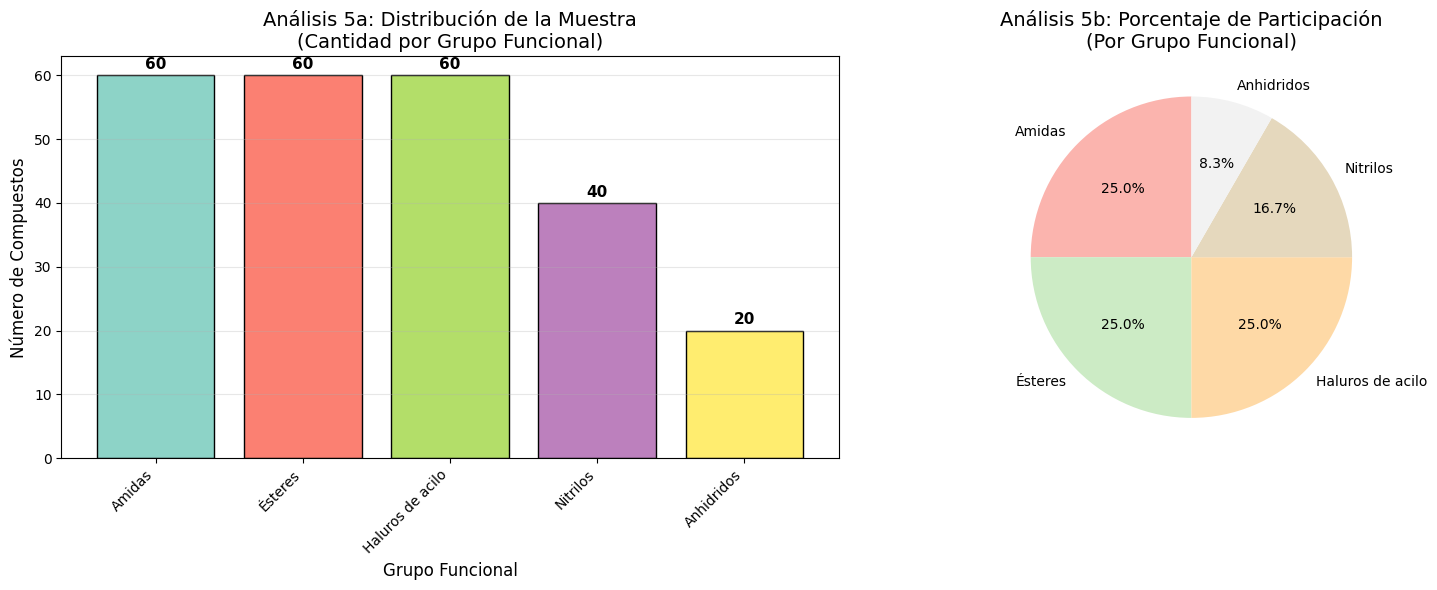


 RESULTADOS ANÁLISIS 5:
   • Total de compuestos: 240
   • Grupos representados: 5

     - Amidas: 60 compuestos (25.0%)
     - Ésteres: 60 compuestos (25.0%)
     - Haluros de acilo: 60 compuestos (25.0%)
     - Nitrilos: 40 compuestos (16.7%)
     - Anhidridos: 20 compuestos (8.3%)

    Grupo con MAYOR representación: Amidas (60 compuestos)


In [6]:
# ANÁLISIS 5: Distribución de la Muestra - Barras + Torta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_df = df.dropna(subset=['Grupo_Funcional']).copy()
plot_df['Grupo_Funcional'] = plot_df['Grupo_Funcional'].astype(str).str.strip()
plot_df = plot_df[~plot_df['Grupo_Funcional'].isin(['nan', 'None', ''])]

if len(plot_df) > 0:
    counts = plot_df['Grupo_Funcional'].value_counts()

    # Gráfico de barras
    colors_bar = plt.cm.Set3(np.linspace(0, 1, len(counts)))
    bars = ax1.bar(range(len(counts)), counts.values, color=colors_bar, edgecolor='black')
    ax1.set_xticks(range(len(counts)))
    ax1.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=10)
    ax1.set_xlabel('Grupo Funcional', fontsize=12)
    ax1.set_ylabel('Número de Compuestos', fontsize=12)
    ax1.set_title('Análisis 5a: Distribución de la Muestra\n(Cantidad por Grupo Funcional)', fontsize=14)
    for bar, count in zip(bars, counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Gráfico de torta
    colors_pie = plt.cm.Pastel1(np.linspace(0, 1, len(counts)))
    ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
    ax2.set_title('Análisis 5b: Porcentaje de Participación\n(Por Grupo Funcional)', fontsize=14)

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 5:")
    print(f"   • Total de compuestos: {len(plot_df)}")
    print(f"   • Grupos representados: {len(counts)}\n")
    for grupo, count in counts.items():
        print(f"     - {grupo}: {count} compuestos ({100*count/len(plot_df):.1f}%)")
    print(f"\n    Grupo con MAYOR representación: {counts.index[0]} ({counts.iloc[0]} compuestos)")
else:
    print(" No hay datos de Grupo Funcional para analizar")

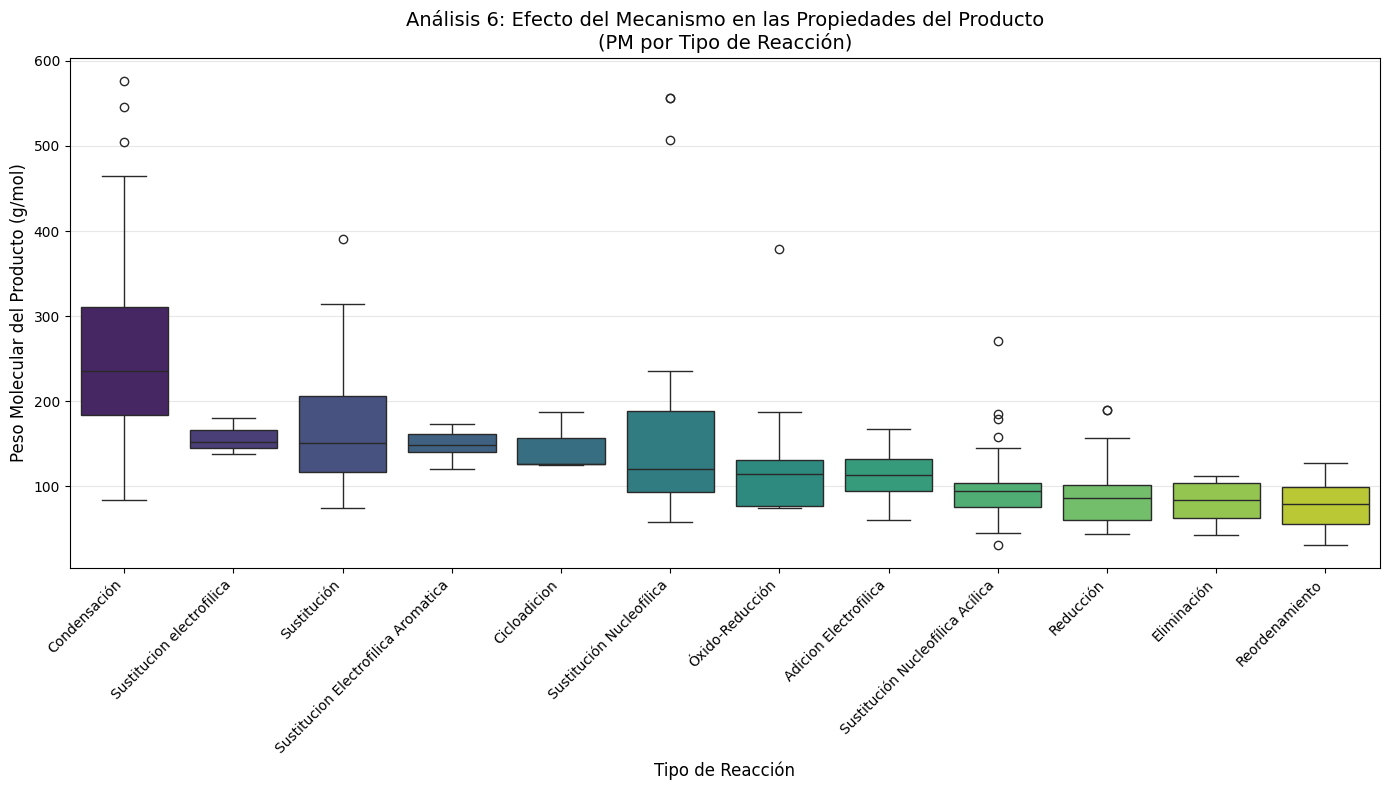


 RESULTADOS ANÁLISIS 6:
   • Condensación: PM medio=251.8 g/mol (n=55)
   • Sustitucion electrofilica: PM medio=156.7 g/mol (n=3)
   • Sustitución: PM medio=172.6 g/mol (n=23)
   • Sustitucion Electrofilica Aromatica: PM medio=148.9 g/mol (n=7)
   • Cicloadicion: PM medio=146.2 g/mol (n=3)
   • Sustitución Nucleofílica: PM medio=199.5 g/mol (n=15)
   • Óxido-Reducción: PM medio=136.1 g/mol (n=9)
   • Adicion Electrofilica: PM medio=114.2 g/mol (n=20)
   • Sustitución Nucleofílica Acílica: PM medio=98.6 g/mol (n=54)
   • Reducción: PM medio=88.7 g/mol (n=29)
   • Eliminación: PM medio=81.7 g/mol (n=7)
   • Reordenamiento: PM medio=77.4 g/mol (n=8)

    Conclusión: Reducción (LiAlH₄) genera productos más ligeros (PM≈89)
      vs Condensación genera productos más pesados (PM≈252).


In [7]:
# ANÁLISIS 6: Tipo_Reacción vs PM_Producto
plt.figure(figsize=(14, 8))

plot_df = df.dropna(subset=['Tipo_Reaccion', 'PM_Producto']).copy()
plot_df = plot_df[(plot_df['PM_Producto'] > 0) & (plot_df['PM_Producto'] < 600)]
plot_df = plot_df[~plot_df['Tipo_Reaccion'].isin(['nan', 'None', ''])]

# Tipos con al menos 3 datos
tipos_validos = plot_df.groupby('Tipo_Reaccion').size()
tipos_validos = tipos_validos[tipos_validos >= 3].index.tolist()
plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(tipos_validos)]

if len(plot_df) >= 5:
    # Ordenar por mediana descendente
    order = plot_df.groupby('Tipo_Reaccion')['PM_Producto'].median().sort_values(ascending=False).index

    sns.boxplot(x='Tipo_Reaccion', y='PM_Producto', data=plot_df, order=order, palette='viridis')

    plt.xlabel('Tipo de Reacción', fontsize=12)
    plt.ylabel('Peso Molecular del Producto (g/mol)', fontsize=12)
    plt.title('Análisis 6: Efecto del Mecanismo en las Propiedades del Producto\n(PM por Tipo de Reacción)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 6:")
    for tipo in order:
        datos = plot_df[plot_df['Tipo_Reaccion'] == tipo]['PM_Producto']
        print(f"   • {tipo}: PM medio={datos.mean():.1f} g/mol (n={len(datos)})")

    if 'Reducción' in order and 'Condensación' in order:
        reduc_mean = plot_df[plot_df['Tipo_Reaccion'] == 'Reducción']['PM_Producto'].mean()
        cond_mean = plot_df[plot_df['Tipo_Reaccion'] == 'Condensación']['PM_Producto'].mean()
        print(f"\n   🔬 Conclusión: Reducción (LiAlH₄) genera productos más ligeros (PM≈{reduc_mean:.0f})")
        print(f"      vs Condensación genera productos más pesados (PM≈{cond_mean:.0f}).")
else:
    print(f" Datos insuficientes: {len(plot_df)} compuestos (mínimo 5)")

<Figure size 1600x1000 with 0 Axes>

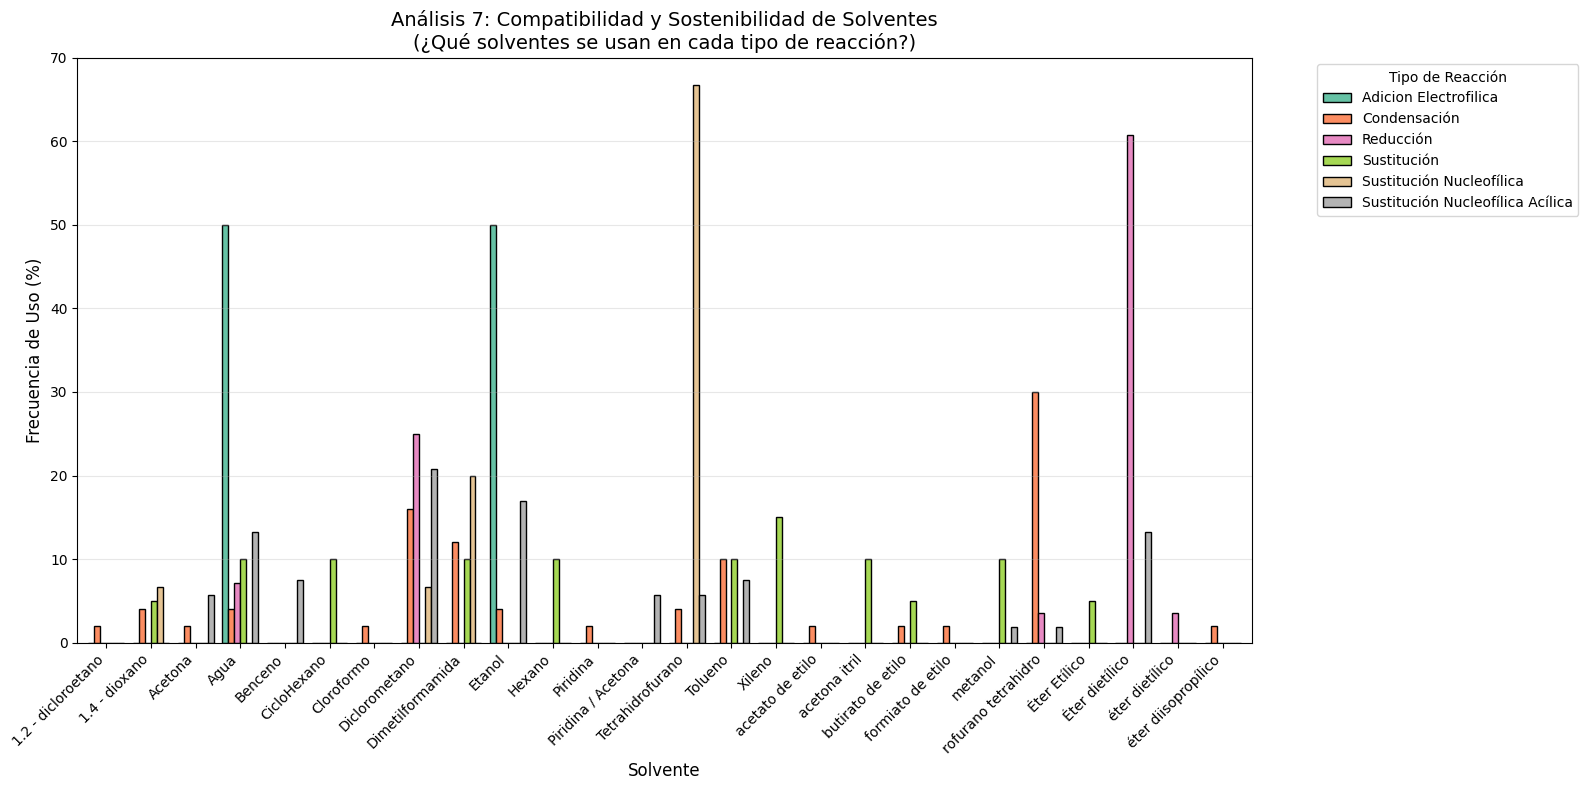


 RESULTADOS ANÁLISIS 7 (Sostenibilidad):
   • Tipos de reacción analizados: Sustitución Nucleofílica Acílica, Condensación, Reducción, Sustitución, Adicion Electrofilica, Sustitución Nucleofílica

    SOLVENTES VERDES: Agua, Etanol, Éter
    SOLVENTES TÓXICOS: Benceno, Cloroformo, Diclorometano, Tolueno

   • Solventes más utilizados (general):
      Diclorometano: 27 reacciones
      Éter dietílico: 24 reacciones
      Agua: 23 reacciones
      Etanol: 21 reacciones
      rofurano tetrahidro: 17 reacciones


In [8]:
# ANÁLISIS 7: Tipo_Reaccion vs Nombre_Solvente_1 - Barras Agrupadas (MODIFICADO)
plt.figure(figsize=(16, 10))

plot_df = df.dropna(subset=['Tipo_Reaccion', 'Nombre_Solvente_1']).copy()
plot_df['Nombre_Solvente_1'] = plot_df['Nombre_Solvente_1'].astype(str).str.strip()
plot_df['Tipo_Reaccion'] = plot_df['Tipo_Reaccion'].astype(str).str.strip()

# Limpiar valores no válidos en solventes
solventes_invalidos = ['0', 'nan', 'None', '', '0;0', '0;0;0', ';']
plot_df = plot_df[~plot_df['Nombre_Solvente_1'].isin(solventes_invalidos)]

# Seleccionar los tipos de reacción más frecuentes (mínimo 4 ocurrencias)
reacciones_counts = plot_df['Tipo_Reaccion'].value_counts()
reacciones_top = reacciones_counts[reacciones_counts >= 4].head(6).index.tolist()
plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(reacciones_top)]

if len(plot_df) > 0:
    # Tabla de contingencia normalizada (porcentajes por tipo de reacción)
    cross_tab = pd.crosstab(plot_df['Tipo_Reaccion'], plot_df['Nombre_Solvente_1'], normalize='index') * 100

    # Gráfico de barras agrupadas
    cross_tab.T.plot(kind='bar', figsize=(16, 8), width=0.8, colormap='Set2', edgecolor='black')

    plt.xlabel('Solvente', fontsize=12)
    plt.ylabel('Frecuencia de Uso (%)', fontsize=12)
    plt.title('Análisis 7: Compatibilidad y Sostenibilidad de Solventes\n(¿Qué solventes se usan en cada tipo de reacción?)', fontsize=14)
    plt.legend(title='Tipo de Reacción', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 7 (Sostenibilidad):")
    print(f"   • Tipos de reacción analizados: {', '.join(reacciones_top)}")
    print("\n    SOLVENTES VERDES: Agua, Etanol, Éter")
    print("    SOLVENTES TÓXICOS: Benceno, Cloroformo, Diclorometano, Tolueno")

    # Identificar solventes más utilizados en general
    solventes_uso = plot_df['Nombre_Solvente_1'].value_counts().head(5)
    print("\n   • Solventes más utilizados (general):")
    for solvent, count in solventes_uso.items():
        peligro = "" if solvent.lower() in ['benceno', 'cloroformo', 'diclorometano', 'tolueno'] else ""
        print(f"     {peligro} {solvent}: {count} reacciones")
else:
    print(" Datos insuficientes para este análisis")

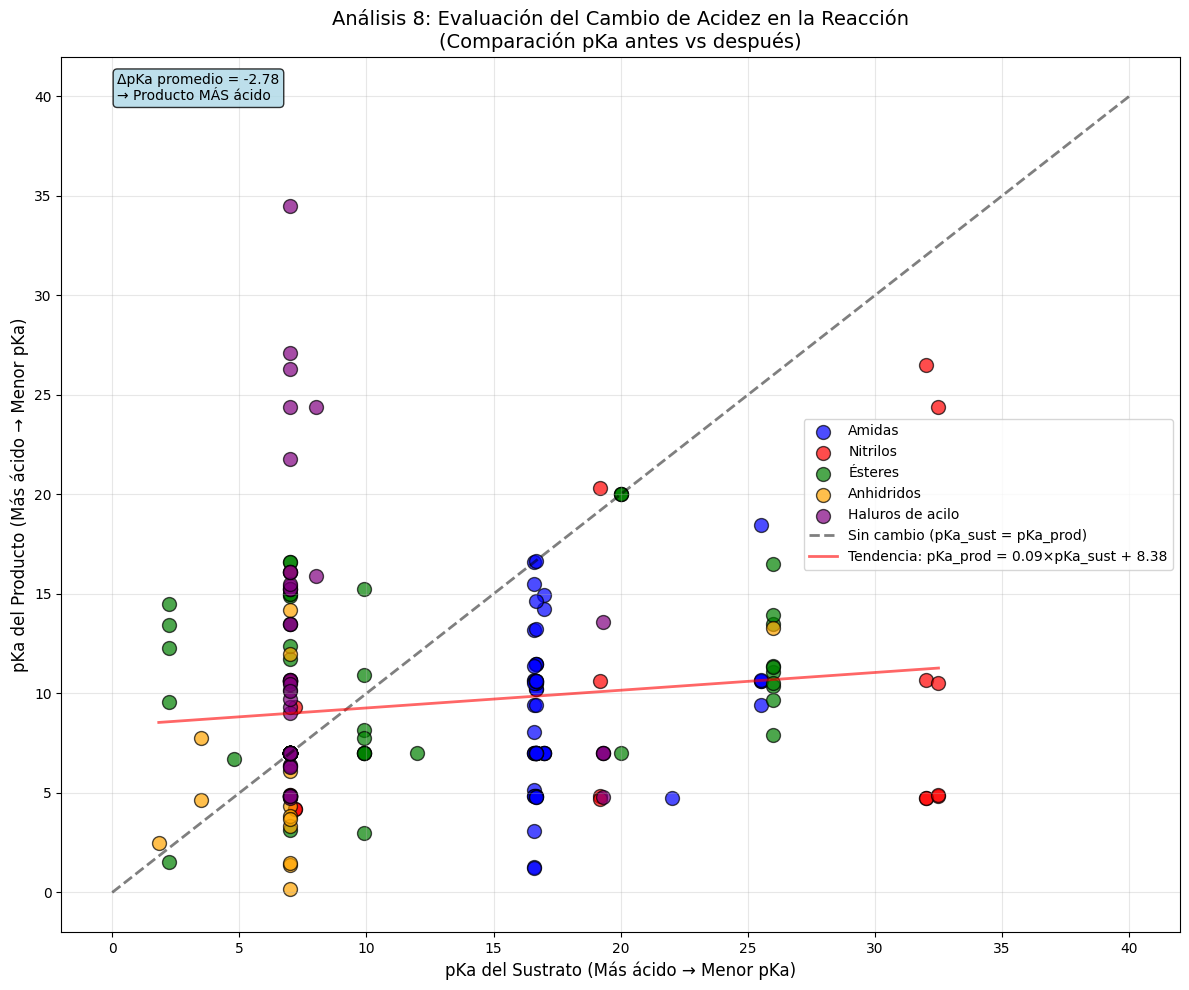


 RESULTADOS ANÁLISIS 8:
   • N° reacciones analizadas: 223
   • Cambio promedio de pKa: Δ = -2.78
   •  Los productos son MÁS ácidos que los sustratos
      → Ejemplo: Una amida se hidroliza a ácido carboxílico


In [9]:
# ANÁLISIS 8: pKa_Sustrato vs pKa_Producto
plt.figure(figsize=(12, 10))

plot_df = df.dropna(subset=['pKa_Sustrato', 'pKa_Producto', 'Grupo_Funcional']).copy()
plot_df = plot_df[(plot_df['pKa_Sustrato'] > 0) & (plot_df['pKa_Sustrato'] < 40)]
plot_df = plot_df[(plot_df['pKa_Producto'] > 0) & (plot_df['pKa_Producto'] < 40)]
plot_df['ΔpKa'] = plot_df['pKa_Producto'] - plot_df['pKa_Sustrato']

if len(plot_df) >= 3:
    # Colores por grupo funcional
    colores_grupos = {'Amidas': 'blue', 'Nitrilos': 'red', 'Ésteres': 'green',
                      'Anhidridos': 'orange', 'Haluros de acilo': 'purple'}

    for grupo, color in colores_grupos.items():
        subset = plot_df[plot_df['Grupo_Funcional'] == grupo]
        if len(subset) > 0:
            plt.scatter(subset['pKa_Sustrato'], subset['pKa_Producto'],
                       c=color, label=grupo, s=100, alpha=0.7, edgecolors='black')

    # Línea de referencia (sin cambio)
    plt.plot([0, 40], [0, 40], 'k--', alpha=0.5, linewidth=2, label='Sin cambio (pKa_sust = pKa_prod)')

    # Línea de tendencia general
    if len(plot_df) > 3:
        z = np.polyfit(plot_df['pKa_Sustrato'], plot_df['pKa_Producto'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_df['pKa_Sustrato'].min(), plot_df['pKa_Sustrato'].max(), 100)
        plt.plot(x_line, p(x_line), 'r-', alpha=0.6, linewidth=2,
                label=f'Tendencia: pKa_prod = {z[0]:.2f}×pKa_sust + {z[1]:.2f}')

    plt.xlabel('pKa del Sustrato (Más ácido → Menor pKa)', fontsize=12)
    plt.ylabel('pKa del Producto (Más ácido → Menor pKa)', fontsize=12)
    plt.title('Análisis 8: Evaluación del Cambio de Acidez en la Reacción\n(Comparación pKa antes vs después)', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    # Anotación del cambio promedio
    cambio_promedio = plot_df['ΔpKa'].mean()
    plt.text(0.05, 0.95, f'ΔpKa promedio = {cambio_promedio:.2f}\n{"→ Producto MENOS ácido" if cambio_promedio > 0 else "→ Producto MÁS ácido"}',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print(f"\n RESULTADOS ANÁLISIS 8:")
    print(f"   • N° reacciones analizadas: {len(plot_df)}")
    print(f"   • Cambio promedio de pKa: Δ = {cambio_promedio:.2f}")

    if cambio_promedio > 0:
        print(f"   •  Los productos son MENOS ácidos (más básicos) que los sustratos")
        print(f"      → Ejemplo: Un nitrilo (pKa bajo) se transforma en amina (pKa alto)")
    else:
        print(f"   •  Los productos son MÁS ácidos que los sustratos")
        print(f"      → Ejemplo: Una amida se hidroliza a ácido carboxílico")
else:
    print(f" Datos insuficientes: {len(plot_df)} reacciones (mínimo 3)")

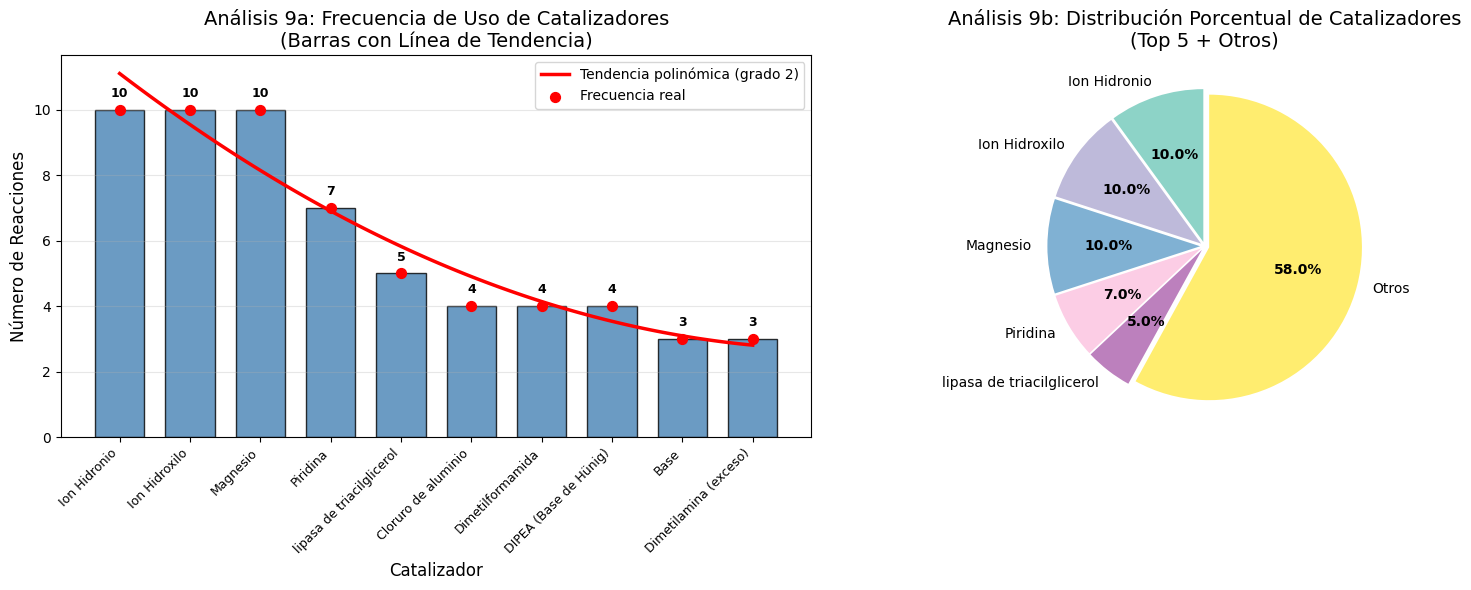


 RESULTADOS DEL ANÁLISIS 9: EFICIENCIA CATALÍTICA
   • Total de reacciones con catalizador registrado: 100
   • Número de catalizadores diferentes: 37
   • Catalizador MÁS utilizado: 'Ion Hidronio' (10 reacciones)
     → Representa el 10.0% del total de reacciones con catalizador

    Top 10 catalizadores más utilizados:
      1. Ion Hidronio: 10 reacciones (10.0%)
      2. Ion Hidroxilo: 10 reacciones (10.0%)
      3. Magnesio: 10 reacciones (10.0%)
      4. Piridina: 7 reacciones (7.0%)
      5. lipasa de triacilglicerol: 5 reacciones (5.0%)
      6. Cloruro de aluminio: 4 reacciones (4.0%)
      7. Dimetilformamida: 4 reacciones (4.0%)
      8. DIPEA (Base de Hünig): 4 reacciones (4.0%)
      9. Base: 3 reacciones (3.0%)
      10. Dimetilamina (exceso): 3 reacciones (3.0%)

    Análisis de la línea de tendencia:
      La línea de tendencia polinómica muestra una caída pronunciada
      después del catalizador más utilizado, lo que indica que
      pocos catalizadores concentran la 

In [12]:
# ANÁLISIS 9: Nombre_Catalizador_1 vs Conteo de Reacciones (Eficiencia Catalítica)
# Gráficos: Barras con línea de tendencia + Torta

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# === PREPARACIÓN DE DATOS ===
# Filtrar datos válidos de catalizador
plot_df = df.dropna(subset=['Nombre_Catalizador_1']).copy()
plot_df['Nombre_Catalizador_1'] = plot_df['Nombre_Catalizador_1'].astype(str).str.strip()

# Limpiar valores no válidos
valores_invalidos = ['0', 'nan', 'None', '', ';', '0;0', '0;0;0', '0;0;0;0']
plot_df = plot_df[~plot_df['Nombre_Catalizador_1'].isin(valores_invalidos)]

# Si hay múltiples catalizadores separados por ';', tomar el primero
plot_df['Catalizador_Principal'] = plot_df['Nombre_Catalizador_1'].str.split(';').str[0].str.strip()
plot_df = plot_df[~plot_df['Catalizador_Principal'].isin(valores_invalidos)]

if len(plot_df) > 0:
    # Contar frecuencias de cada catalizador
    catalyst_counts = plot_df['Catalizador_Principal'].value_counts()

    # === GRÁFICO 1: BARRAS CON LÍNEA DE TENDENCIA ===
    # Tomar los 10 catalizadores más frecuentes para mejor visualización
    top_n = min(10, len(catalyst_counts))
    top_catalysts = catalyst_counts.head(top_n)

    # Posiciones para las barras
    x_pos = np.arange(len(top_catalysts))
    y_values = top_catalysts.values

    # Barras
    bars = ax1.bar(x_pos, y_values, color='steelblue', edgecolor='black', alpha=0.8, width=0.7)

    # Línea de tendencia (polinomio de grado 2)
    if len(x_pos) >= 3:
        # Ajustar polinomio de grado 2
        z = np.polyfit(x_pos, y_values, 2)
        p = np.poly1d(z)
        x_smooth = np.linspace(x_pos.min(), x_pos.max(), 100)
        y_smooth = p(x_smooth)
        ax1.plot(x_smooth, y_smooth, 'r-', linewidth=2.5, label=f'Tendencia polinómica (grado 2)')
        ax1.scatter(x_pos, y_values, color='red', s=50, zorder=5, label='Frecuencia real')

    # Etiquetas y formato
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(top_catalysts.index, rotation=45, ha='right', fontsize=9)
    ax1.set_xlabel('Catalizador', fontsize=12)
    ax1.set_ylabel('Número de Reacciones', fontsize=12)
    ax1.set_title('Análisis 9a: Frecuencia de Uso de Catalizadores\n(Barras con Línea de Tendencia)', fontsize=14)

    # Añadir valores sobre las barras
    for bar, val in zip(bars, y_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(loc='upper right')

    # === GRÁFICO 2: DIAGRAMA DE TORTA ===
    # Tomar los 5 catalizadores más frecuentes para la torta
    top5_catalysts = catalyst_counts.head(5)
    otros_count = catalyst_counts.iloc[5:].sum() if len(catalyst_counts) > 5 else 0

    # Datos para la torta
    if otros_count > 0:
        torta_labels = list(top5_catalysts.index) + ['Otros']
        torta_values = list(top5_catalysts.values) + [otros_count]
    else:
        torta_labels = list(top5_catalysts.index)
        torta_values = list(top5_catalysts.values)

    # Colores
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(torta_labels)))

    # Gráfico de torta
    wedges, texts, autotexts = ax2.pie(torta_values, labels=torta_labels, autopct='%1.1f%%',
                                        colors=colors_pie, startangle=90, explode=[0.03]*len(torta_labels))
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    ax2.set_title('Análisis 9b: Distribución Porcentual de Catalizadores\n(Top 5 + Otros)', fontsize=14)

    plt.tight_layout()
    plt.show()

    # === IMPRESIÓN DE RESULTADOS ===
    print("\n" + "="*60)
    print(" RESULTADOS DEL ANÁLISIS 9: EFICIENCIA CATALÍTICA")
    print("="*60)
    print(f"   • Total de reacciones con catalizador registrado: {len(plot_df)}")
    print(f"   • Número de catalizadores diferentes: {len(catalyst_counts)}")
    print(f"   • Catalizador MÁS utilizado: '{catalyst_counts.index[0]}' ({catalyst_counts.iloc[0]} reacciones)")

    # Calcular porcentaje del catalizador principal
    pct_principal = 100 * catalyst_counts.iloc[0] / len(plot_df)
    print(f"     → Representa el {pct_principal:.1f}% del total de reacciones con catalizador")

    print("\n    Top 10 catalizadores más utilizados:")
    for i, (cat, count) in enumerate(catalyst_counts.head(10).items(), 1):
        pct = 100 * count / len(plot_df)
        print(f"      {i}. {cat}: {count} reacciones ({pct:.1f}%)")

    # Análisis de la línea de tendencia
    if len(top_catalysts) >= 3:
        print("\n    Análisis de la línea de tendencia:")
        print(f"      La línea de tendencia polinómica muestra una caída pronunciada")
        print(f"      después del catalizador más utilizado, lo que indica que")
        print(f"      pocos catalizadores concentran la mayoría de las reacciones.")

    # Concentración de uso
    top3_pct = 100 * catalyst_counts.head(3).sum() / len(plot_df)
    top5_pct = 100 * catalyst_counts.head(5).sum() / len(plot_df)
    print(f"\n    Concentración del uso:")
    print(f"      • Top 3 catalizadores: {top3_pct:.1f}% de las reacciones")
    print(f"      • Top 5 catalizadores: {top5_pct:.1f}% de las reacciones")

    # Discusión sobre eficiencia y costos
    print("\n    DISCUSIÓN SOBRE EFICIENCIA CATALÍTICA:")
    print(f"      • El catalizador '{catalyst_counts.index[0]}' es el más recurrente,")
    print(f"        lo que sugiere que es eficiente, económico o versátil.")
    print(f"      • Los {len(catalyst_counts)} catalizadores diferentes indican diversidad")
    print(f"        de mecanismos de reacción en el proyecto.")
    if top3_pct > 50:
        print(f"      • ALTA concentración: El {top3_pct:.0f}% de las reacciones usan solo 3 catalizadores.")
        print(f"        → Esto puede reducir costos de inventario y estandarizar procesos.")
    else:
        print(f"      • BAJA concentración: Los catalizadores están bien distribuidos.")
        print(f"        → Mayor especialización pero posible aumento de costos.")

else:
    print(" No hay datos de catalizadores válidos para analizar")
    print("   Verifica que la columna 'Nombre_Catalizador_1' contenga información relevante.")